In [42]:
import seaborn as sns
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### Load Data

In [43]:
# dataset = pd.read_excel('dataset/covid.xlsx')
url = 'https://raw.githubusercontent.com/MachineLearnia/Python-Machine-Learning/master/Dataset/dataset.csv'
dataset = pd.read_csv(url, index_col=0, encoding = "ISO-8859-1")

In [44]:
df = dataset.__deepcopy__()

In [45]:
df.shape

(5644, 110)

In [46]:
df.head()

,Patient age quantile,SARS-Cov-2 exam result,"Patient addmited to regular ward (1=yes, 0=no)","Patient addmited to semi-intensive unit (1=yes, 0=no)","Patient addmited to intensive care unit (1=yes, 0=no)",Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,...,Hb saturation (arterial blood gases),pCO2 (arterial blood gas analysis),Base excess (arterial blood gas analysis),pH (arterial blood gas analysis),Total CO2 (arterial blood gas analysis),HCO3 (arterial blood gas analysis),pO2 (arterial blood gas analysis),Arteiral Fio2,Phosphor,ctO2 (arterial blood gas analysis)
Patient ID,,,,,,,,,,,,,,,,,,,,,
44477f75e8169d2,13,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
126e9dd13932f68,17,negative,0,0,0,0.236515,-0.02234,-0.517413,0.010677,0.102004,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
a46b4402a0e5696,8,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
f7d619a94f97c45,5,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
d9e41465789c2b5,15,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Rename handy values

In [47]:
df = df.rename(columns={"SARS-Cov-2 exam result": "CovidResult", "Patient age quantile": "Age"}).__deepcopy__()

### Remove 90% nan data

In [48]:
missing_rates = df.isna().sum()/df.shape[0]
missing_rates

Age                                                      0.000000
CovidResult                                              0.000000
Patient addmited to regular ward (1=yes, 0=no)           0.000000
Patient addmited to semi-intensive unit (1=yes, 0=no)    0.000000
Patient addmited to intensive care unit (1=yes, 0=no)    0.000000
                                                           ...   
HCO3 (arterial blood gas analysis)                       0.995216
pO2 (arterial blood gas analysis)                        0.995216
Arteiral Fio2                                            0.996456
Phosphor                                                 0.996456
ctO2 (arterial blood gas analysis)                       0.995216
Length: 110, dtype: float64

In [49]:
df = df[df.columns[missing_rates < 0.9]]

In [50]:
df.shape

(5644, 38)

### Sort viral/blood/key data

In [51]:
missing_rates = df.isna().sum()/df.shape[0]
missing_rates.sort_values()

Age                                                      0.000000
CovidResult                                              0.000000
Patient addmited to regular ward (1=yes, 0=no)           0.000000
Patient addmited to semi-intensive unit (1=yes, 0=no)    0.000000
Patient addmited to intensive care unit (1=yes, 0=no)    0.000000
Respiratory Syncytial Virus                              0.760099
Influenza A                                              0.760099
Influenza B                                              0.760099
Inf A H1N1 2009                                          0.760454
CoronavirusOC43                                          0.760454
Metapneumovirus                                          0.760454
Parainfluenza 4                                          0.760454
Adenovirus                                               0.760454
Chlamydophila pneumoniae                                 0.760454
Parainfluenza 3                                          0.760454
Coronaviru

In [52]:
viral_columns = list(df.columns[(missing_rates > 0.75) & (missing_rates < 0.77)])
# viral_columns.remove('Parainfluenza 2')

In [53]:
blood_columns = list(df.columns[(missing_rates > 0.89) & (missing_rates < 0.9)])

In [54]:
key_columns = ['Age', 'CovidResult']

In [55]:
df.columns

Index(['Age', 'CovidResult', 'Patient addmited to regular ward (1=yes, 0=no)',
       'Patient addmited to semi-intensive unit (1=yes, 0=no)',
       'Patient addmited to intensive care unit (1=yes, 0=no)', 'Hematocrit',
       'Hemoglobin', 'Platelets', 'Mean platelet volume ', 'Red blood Cells',
       'Lymphocytes', 'Mean corpuscular hemoglobin concentration (MCHC)',
       'Leukocytes', 'Basophils', 'Mean corpuscular hemoglobin (MCH)',
       'Eosinophils', 'Mean corpuscular volume (MCV)', 'Monocytes',
       'Red blood cell distribution width (RDW)',
       'Respiratory Syncytial Virus', 'Influenza A', 'Influenza B',
       'Parainfluenza 1', 'CoronavirusNL63', 'Rhinovirus/Enterovirus',
       'Coronavirus HKU1', 'Parainfluenza 3', 'Chlamydophila pneumoniae',
       'Adenovirus', 'Parainfluenza 4', 'Coronavirus229E', 'CoronavirusOC43',
       'Inf A H1N1 2009', 'Bordetella pertussis', 'Metapneumovirus',
       'Parainfluenza 2', 'Influenza B, rapid test',
       'Influenza A, rapi

In [56]:
df = df[key_columns + blood_columns + viral_columns]

In [57]:
df.head()

,Age,CovidResult,Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,Lymphocytes,Mean corpuscular hemoglobin concentration (MCHC),Leukocytes,...,Parainfluenza 3,Chlamydophila pneumoniae,Adenovirus,Parainfluenza 4,Coronavirus229E,CoronavirusOC43,Inf A H1N1 2009,Bordetella pertussis,Metapneumovirus,Parainfluenza 2
Patient ID,,,,,,,,,,,,,,,,,,,,,
44477f75e8169d2,13,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
126e9dd13932f68,17,negative,0.236515,-0.02234,-0.517413,0.010677,0.102004,0.318366,-0.95079,-0.09461,...,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected
a46b4402a0e5696,8,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
f7d619a94f97c45,5,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
d9e41465789c2b5,15,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected


## Pre-processing

### transform categorical value to numeric value

In [58]:
def encoding(df):
  def foo(val):
    if (val == 'detected' or val == 'positive'):
      return 1
    elif (val == 'not_detected' or val == 'negative'):
      return 0
    else:
      return val
  return df.map(foo)

In [59]:
# df = df.map(encoding).__deepcopy__()

### Add is_sick column for future feature selection

In [60]:
# is_sick_series = df[viral_columns].sum(axis=1)
# df['is_sick'] = is_sick_series

### Imputing **nan**

In [61]:
from sklearn.impute import SimpleImputer

In [62]:
def imputation(df, strategy='drop', fill_value=-999):
  
  if strategy == 'drop':
    return df.dropna();
  else:
    imputer = SimpleImputer(strategy=strategy, fill_value=fill_value)
    # df['is_missing'] = df.isna().any(axis=1).astype(int)
    # col, index = df.columns, df.index
    # idf = pd.DataFrame(imputer.fit_transform(df))
    # idf.columns = col
    # idf.index = index
    return pd.DataFrame(imputer.fit_transform(df))

In [63]:
def feature_engineering(df):
  df['is_sick'] = df[viral_columns].sum(axis=1)
  # df = df.drop('Parainfluenza 2', axis=1)
  df = df.drop(viral_columns, axis=1)
  return df

### Define preprocessing method

In [64]:
def preprocessing(_df):
  _df = encoding(_df)
  _df = feature_engineering(_df)
  _df = imputation(_df, strategy='drop')

  X = _df.drop('CovidResult', axis=1)
  print(f'Shape of X: {X.shape}')
  y = _df['CovidResult']
  print(f'Shape of y: {y.shape}')
  print(f'{y.value_counts()}')
  return X, y

### Train/Test split

In [65]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, random_state=0)

print(f'train_set \n {train_set['CovidResult'].value_counts()}')
print(f'test_set \n {test_set['CovidResult'].value_counts()}')

train_set 
 CovidResult
negative    4068
positive     447
Name: count, dtype: int64
test_set 
 CovidResult
negative    1018
positive     111
Name: count, dtype: int64


In [66]:
X_train, y_train = preprocessing(train_set)
X_test, y_test = preprocessing(test_set)

Shape of X: (487, 16)
Shape of y: (487,)
CovidResult
0    422
1     65
Name: count, dtype: int64
Shape of X: (111, 16)
Shape of y: (111,)
CovidResult
0    95
1    16
Name: count, dtype: int64


### Modelisation

In [67]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC, LinearSVC

### Let's make a full pipeline

In [68]:
from sklearn.preprocessing import PolynomialFeatures


pp = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), SelectKBest(k=5))

In [69]:
# model = DecisionTreeClassifier(random_state=0)
# model = RandomForestClassifier(random_state=0)

from pandas.core.common import random_state
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler


RandomForest = make_pipeline(pp, RandomForestClassifier(random_state=0))
DecisionTree = make_pipeline(pp, DecisionTreeClassifier(random_state=0))
SVC = make_pipeline(pp, StandardScaler(), SVC(random_state=0))
LSVC = make_pipeline(pp, StandardScaler(), LinearSVC(random_state=0))
SGD = make_pipeline(pp, StandardScaler(), SGDClassifier(random_state=0))
KNN = make_pipeline(pp, StandardScaler(), KNeighborsClassifier(n_neighbors=5))

models = {
    "RandomForest": RandomForest,
    "DecisionTree": DecisionTree,
    "SVC": SVC,
    "LSVC": LSVC,
    "SGD": SGD,
    "KNN": KNN
}

model = make_pipeline(SelectKBest(k=5), DecisionTreeClassifier(random_state=0))

### Compute and metrics

In [70]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import learning_curve

In [71]:
def evaluation(X_test, y_test, model):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  print(confusion_matrix(y_test, y_pred))
  print(classification_report(y_test, y_pred))

  N, train_score, val_score = learning_curve(model, X_train, y_train, cv=4, train_sizes=np.linspace(0.1, 1, 10), scoring='f1')
  plt.plot(N, train_score.mean(axis=1))
  plt.plot(N, val_score.mean(axis=1))
  
  plt.show()


* Notes
  * En dropant les nan, en encodant les valeurs catégorique en string, on a **recall**: *0.17* et **f1**: *0.25*
    * Mon modèle est en très clair overfitting (**f1**: *1* sur mon training set)
  * En dropant la colonne *Parainfluenza 2* qu'on a détecté comme inutile dans notre analyse exploratoire, on a **recall**: *0.42* et **f1**: *0.45*
    * De ça, j'emets l'hypothèse qu'il y a trop de features dans mon dataset, j'envisage d'essayer de faire de la feature selection, du pca, et/ou du feature engineering pour tenter de compresser les features
    * Mon modèle reste cependant en overfitting
  * En utilisant le bagging (utilisation de plsrs modèle sur échantillon du training set pour lutter contre overfitting) on remarque que ça n'a pas trop d'effet
  * Bcp de feature sont inutile pour notre modèle d'arbre, on retire les colonne virus et on ajoute une colonne *is_sick* qui résume les colonnes virus, on a **recall: 0.19 - f1: 0.27**
  * On fait de la Feature Selection avec SelectKBest avant un RandomForstClassifier, on a **recall: 0.44 - f1: 0.50**, toujours en overfitting
  * Avec un simple DecisionTree on a **recall: 0.62 - f1: 0.61** mais on est toujours en overfitting

* Effet permanent
  * On garde la colonne droppé *Parainfluenza 2*

[[88  7]
 [ 6 10]]
              precision    recall  f1-score   support

           0       0.94      0.93      0.93        95
           1       0.59      0.62      0.61        16

    accuracy                           0.88       111
   macro avg       0.76      0.78      0.77       111
weighted avg       0.89      0.88      0.88       111



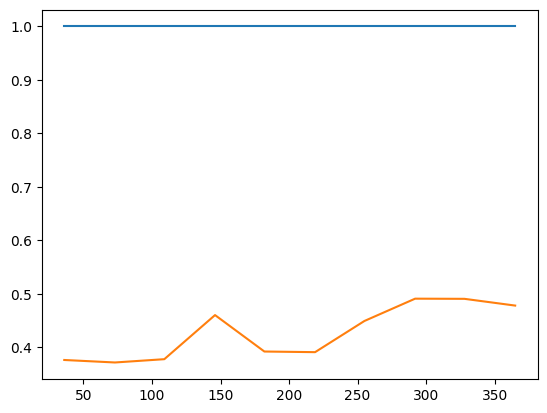

In [72]:
evaluation(X_test, y_test, model)

Evaluating model: RandomForest on test set
[[90  5]
 [12  4]]
              precision    recall  f1-score   support

           0       0.88      0.95      0.91        95
           1       0.44      0.25      0.32        16

    accuracy                           0.85       111
   macro avg       0.66      0.60      0.62       111
weighted avg       0.82      0.85      0.83       111



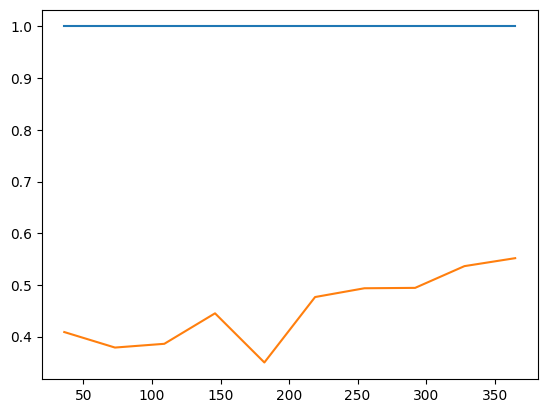


############################################################

Evaluating model: DecisionTree on test set
[[84 11]
 [13  3]]
              precision    recall  f1-score   support

           0       0.87      0.88      0.88        95
           1       0.21      0.19      0.20        16

    accuracy                           0.78       111
   macro avg       0.54      0.54      0.54       111
weighted avg       0.77      0.78      0.78       111



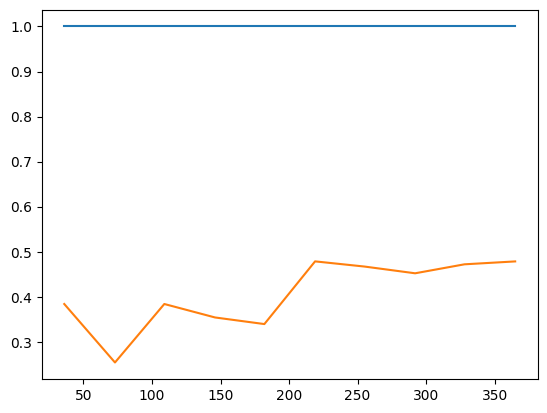


############################################################

Evaluating model: SVC on test set
[[92  3]
 [12  4]]
              precision    recall  f1-score   support

           0       0.88      0.97      0.92        95
           1       0.57      0.25      0.35        16

    accuracy                           0.86       111
   macro avg       0.73      0.61      0.64       111
weighted avg       0.84      0.86      0.84       111



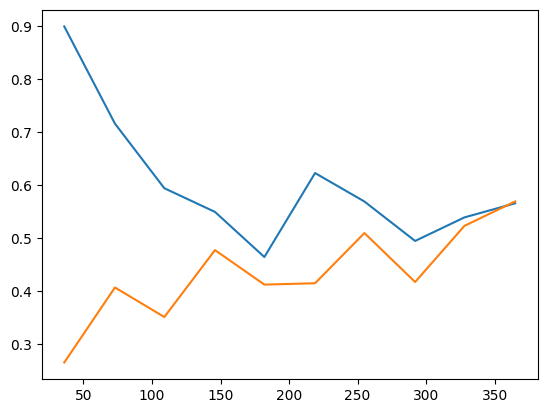


############################################################

Evaluating model: LSVC on test set
[[92  3]
 [14  2]]
              precision    recall  f1-score   support

           0       0.87      0.97      0.92        95
           1       0.40      0.12      0.19        16

    accuracy                           0.85       111
   macro avg       0.63      0.55      0.55       111
weighted avg       0.80      0.85      0.81       111



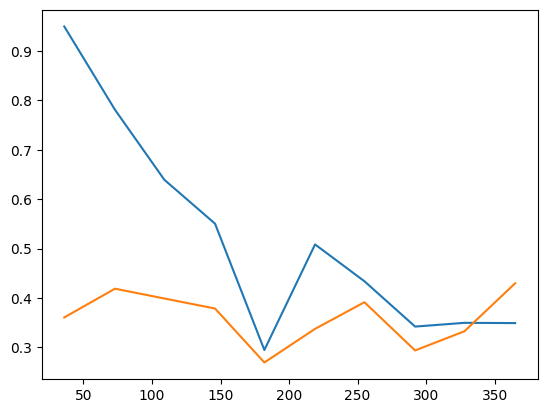


############################################################

Evaluating model: SGD on test set
[[93  2]
 [14  2]]
              precision    recall  f1-score   support

           0       0.87      0.98      0.92        95
           1       0.50      0.12      0.20        16

    accuracy                           0.86       111
   macro avg       0.68      0.55      0.56       111
weighted avg       0.82      0.86      0.82       111



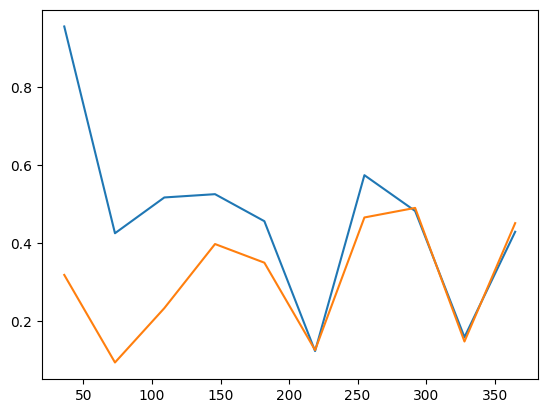


############################################################

Evaluating model: KNN on test set
[[89  6]
 [12  4]]
              precision    recall  f1-score   support

           0       0.88      0.94      0.91        95
           1       0.40      0.25      0.31        16

    accuracy                           0.84       111
   macro avg       0.64      0.59      0.61       111
weighted avg       0.81      0.84      0.82       111



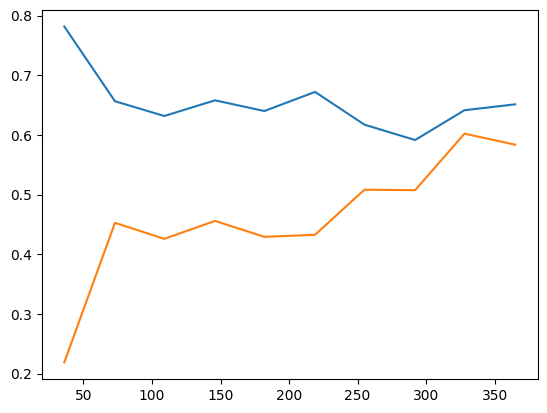


############################################################



In [73]:
for name, m in models.items():
    print(f'Evaluating model: {name} on test set')
    evaluation(X_test, y_test, m)
    print("\n" + "#"*60 + "\n")

In [74]:
# pd.DataFrame(model.feature_importances_, index=X_train.columns).plot.bar(figsize=(10,5))